# Preprocessing prototype

Manual implementation of the preprocessing decisions from `01_eda.ipynb`, used to validate them before building the production pipeline.

In [5]:
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/train.csv")

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

X = df.drop(columns=["ID", "Segmentation"])

# Бинарные признаки
X["Gender"] = X["Gender"].map({"Male": 1, "Female": 0})
for col in ["Ever_Married", "Graduated"]:
    X[col] = X[col].fillna(X[col].mode()[0]).map({"Yes": 1, "No": 0})

# Ordinal
X["Spending_Score"] = X["Spending_Score"].map({"Low": 1, "Average": 2, "High": 3})

# Пропуски в категориях -> отдельная категория
X["Profession"] = X["Profession"].fillna("Missing")
X["Var_1"] = X["Var_1"].fillna("Missing")

# Редкие категории Var_1 -> Other
share = X["Var_1"].value_counts(normalize=True)
rare = share[share < 0.05].index
X["Var_1"] = X["Var_1"].replace(list(rare), "Other")

# One-hot
X = pd.get_dummies(X, columns=["Profession", "Var_1"], dtype=int)

# Числовые пропуски: медиана + флаг пропуска
cols_to_impute = ["Work_Experience", "Family_Size"]
imputer = SimpleImputer(strategy="median", add_indicator=True)
imputed = pd.DataFrame(
    imputer.fit_transform(X[cols_to_impute]),
    columns=imputer.get_feature_names_out(),
    index=X.index,
)
X = X.drop(columns=cols_to_impute).join(imputed)

# Масштабирование
scale_cols = ["Age", "Work_Experience", "Family_Size", "Spending_Score"]
X[scale_cols] = RobustScaler().fit_transform(X[scale_cols])

In [7]:
print(X.isna().sum().sum())   
X.shape
X.dtypes.value_counts()  

0


int64      18
float64     6
Name: count, dtype: int64

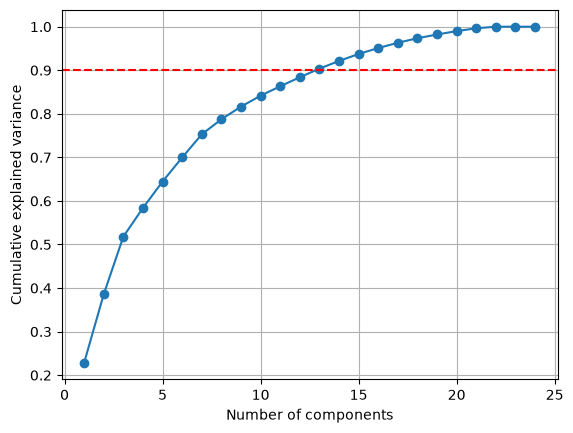

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA().fit(X)
cum_var = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.9, color="red", linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.show()

## Conclusions

- Result: 8068 rows × 24 features, no missing values, all features numeric.
- PCA: 13 components explain 90% of the variance. The curve is smooth with no clear elbow, so compression is moderate (24 → 13).
- The first 2 components explain ~39% of the variance — enough for an approximate 2D visualization of clusters.
- Next steps: implement the same transformations as a scikit-learn `Pipeline` with `ColumnTransformer` in `src/pipeline.py`, and compare three options in MLflow: no PCA, PCA with 13 components, PCA with 2 components.